# Question 1 — data review, visualisation and monthly forecasting

This notebook provides an auditable workflow for the prepared physical-activity panels and is intentionally numbered 02 after the unified preparation notebook:

1. load, clean and validate all annual and monthly outputs;
2. show simple annual and monthly charts at London, Inner/Outer and borough levels;
3. evaluate a **fixed-origin 12-month forecast** on the final year (`2022-11` to `2023-10`);
4. compare seasonal naive, Ridge, Random Forest and Gradient Boosting methods;
5. treat COVID as an explicit historical shock in both charts and modelling diagnostics;
6. inspect coefficients, permutation importance, residuals, uncertainty and low-effective-sample sensitivity.

The annual panels were already aggregated with `wt_final`; the monthly panels were already aggregated with `wt_time`. They must not be survey-weighted a second time. `effective_n` is used only as a reliability/sample weight for fitting and evaluation, never as a predictor.

To prevent target leakage, every survey-derived predictor used for the final-year forecast is lagged by exactly 12 months. Thus all inputs for the entire test year were available at the forecast origin in October 2022. No contemporaneous activity or MEMS variable is used. The two COVID fields are different: they are pre-defined current-month and lag-source calendar indicators, not survey outcomes.

In [1]:
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer, r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_START_MONTH = 85
TEST_END_MONTH = 96
ALR_EPSILON = 1e-4
TARGETS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
TARGET_LABELS = {
    'inactive_rate': 'Inactive',
    'fairly_active_rate': 'Fairly active',
    'active_rate': 'Active',
}
COMPOSITION_FEATURES = [
    'older_adult_rate', 'limiting_disability_rate', 'online_response_rate'
]
ACTIVITY_PREFIXES = ('MONTHS12_RATE_', 'DAYS_ANY_RATE_', 'DAYS_2PLUS_RATE_')

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'physical_activity_analysis' else cwd
DATA_DIR = PROJECT_ROOT / 'physical_activity_analysis' / 'csv_outputs'
OUTPUT_DIR = PROJECT_ROOT / 'physical_activity_analysis' / 'prediction_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    'london_annual': DATA_DIR / 'question1_london_annual.csv',
    'area_annual': DATA_DIR / 'question1_inner_outer_annual.csv',
    'borough_annual': DATA_DIR / 'question1_borough_annual.csv',
    'london_monthly': DATA_DIR / 'question1_london_monthly.csv',
    'area_monthly': DATA_DIR / 'question1_inner_outer_monthly.csv',
    'borough_monthly': DATA_DIR / 'question1_borough_monthly.csv',
}
assert all(path.exists() for path in PATHS.values())

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

# London/England calendar periods used consistently in charts and modelling.
# End dates are exclusive so that the full final month is included.
COVID_PERIODS = (
    {
        'label': 'Major restrictions and staged reopening',
        'start': pd.Timestamp('2020-03-01'),
        'end': pd.Timestamp('2021-08-01'),
    },
    {
        'label': 'Omicron / Plan B',
        'start': pd.Timestamp('2021-12-01'),
        'end': pd.Timestamp('2022-03-01'),
    },
)


def covid_restriction_flag(dates):
    dates = pd.to_datetime(dates)
    flag = np.zeros(len(dates), dtype=int)
    for period in COVID_PERIODS:
        flag |= ((dates >= period['start']) & (dates < period['end'])).astype(int)
    return flag


def shade_covid_periods(ax, show_labels=False):
    for index, period in enumerate(COVID_PERIODS):
        label = period['label'] if show_labels else None
        ax.axvspan(period['start'], period['end'], color='#78909c', alpha=.12,
                   linewidth=0, label=label, zorder=0)


## 1. Load and standardise the six panels

Date strings are parsed only in memory. Source CSVs are not altered. The three aggregation levels are kept separate because combining them would count the same underlying survey evidence more than once.

In [2]:
panels = {name: pd.read_csv(path) for name, path in PATHS.items()}
for name, frame in panels.items():
    if 'period_start' in frame.columns:
        frame['period_start'] = pd.to_datetime(frame['period_start'], format='%Y-%m')

london_annual = panels['london_annual']
area_annual = panels['area_annual']
borough_annual = panels['borough_annual']
london_monthly = panels['london_monthly']
area_monthly = panels['area_monthly']
borough_monthly = panels['borough_monthly']

activity_columns = [
    column for column in borough_monthly.columns if column.startswith(ACTIVITY_PREFIXES)
]
activity_counts = {
    prefix: sum(column.startswith(prefix) for column in activity_columns)
    for prefix in ACTIVITY_PREFIXES
}

inventory = []
for name, frame in panels.items():
    inventory.append({
        'panel': name,
        'rows': len(frame),
        'columns': len(frame.columns),
        'geographies': frame['geography_name'].nunique(),
        'all-target-missing rows': int(frame[TARGETS].isna().all(axis=1).sum()),
    })
display(pd.DataFrame(inventory))
print('Activity variables:', activity_counts, 'Total:', len(activity_columns))

,panel,rows,columns,geographies,all-target-missing rows
0,london_annual,8,384,1,0
1,area_annual,16,385,2,0
2,borough_annual,256,385,32,0
3,london_monthly,96,387,1,0
4,area_monthly,192,388,2,0
5,borough_monthly,3072,388,32,1


Activity variables: {'MONTHS12_RATE_': 124, 'DAYS_ANY_RATE_': 124, 'DAYS_2PLUS_RATE_': 124} Total: 372


## 2. Data cleaning and quality checks

The checks below stop execution if keys are duplicated, rates leave `[0, 1]`, activity columns change, targets fail to sum to one, or a pre-defined train/test field reappears. Missing survey cells remain missing rather than being converted to zero.

In [3]:
EXPECTED_ROWS = {
    'london_annual': 8, 'area_annual': 16, 'borough_annual': 256,
    'london_monthly': 96, 'area_monthly': 192, 'borough_monthly': 3072,
}
KEYS = {
    'london_annual': ['year'],
    'area_annual': ['year', 'geography_code'],
    'borough_annual': ['year', 'geography_code'],
    'london_monthly': ['month_index'],
    'area_monthly': ['month_index', 'geography_code'],
    'borough_monthly': ['month_index', 'geography_code'],
}

quality_rows = []
for name, frame in panels.items():
    assert len(frame) == EXPECTED_ROWS[name]
    assert not frame.duplicated(KEYS[name]).any()
    assert 'data_split' not in frame.columns
    assert not any(column.startswith(('MEMS7_', 'MEMS7GR_')) for column in frame.columns)
    panel_activity = [column for column in frame.columns if column.startswith(ACTIVITY_PREFIXES)]
    assert panel_activity == activity_columns

    observed = frame[TARGETS].notna().all(axis=1)
    assert frame.loc[observed, TARGETS + COMPOSITION_FEATURES].notna().all().all()
    assert frame.loc[observed, TARGETS + COMPOSITION_FEATURES].apply(
        lambda series: series.between(0, 1)
    ).all().all()
    assert np.allclose(frame.loc[observed, TARGETS].sum(axis=1), 1.0, atol=1e-10)
    assert frame.loc[observed, 'effective_n'].gt(0).all()
    assert frame.loc[observed, activity_columns].stack().between(0, 1).all()

    quality_rows.append({
        'panel': name,
        'observed rows': int(observed.sum()),
        'missing rows': int((~observed).sum()),
        'minimum effective_n': frame.loc[observed, 'effective_n'].min(),
        'median effective_n': frame.loc[observed, 'effective_n'].median(),
        'activity missing cells (%)': 100 * frame[activity_columns].isna().to_numpy().mean(),
    })

quality_summary = pd.DataFrame(quality_rows)
display(quality_summary.style.format({
    'minimum effective_n': '{:.2f}',
    'median effective_n': '{:.2f}',
    'activity missing cells (%)': '{:.3f}',
}))

missing_borough_months = borough_monthly.loc[
    borough_monthly[TARGETS].isna().all(axis=1),
    ['month_index', 'period_start', 'geography_code', 'geography_name'],
]
assert missing_borough_months.to_dict('records') == [{
    'month_index': 60,
    'period_start': pd.Timestamp('2020-10-01'),
    'geography_code': 'E09000002',
    'geography_name': 'Barking and Dagenham',
}]
display(missing_borough_months)

,panel,observed rows,missing rows,minimum effective_n,median effective_n,activity missing cells (%)
0,london_annual,8,0,8669.77,9163.01,0.000
1,area_annual,16,0,3458.68,4569.56,0.000
2,borough_annual,256,0,212.55,294.72,0.000
3,london_monthly,96,0,267.61,746.42,0.000
4,area_monthly,192,0,117.47,366.00,0.000
5,borough_monthly,3071,1,2.80,25.18,0.033


,month_index,period_start,geography_code,geography_name
1888,60,2020-10-01,E09000002,Barking and Dagenham


## 3. Simple annual visualisations

These charts use the annual panels, which were constructed with `wt_final`. Values are already survey-weighted percentages.

COVID cannot be assigned cleanly to whole survey waves because waves run November–October. The 2019/20, 2020/21 and 2021/22 bars are therefore marked as **COVID-overlap waves**, not labelled as wholly pandemic observations. The detailed monthly charts below use exact calendar spans.

Calendar definitions: major restrictions/staged reopening are shown from March 2020 through July 2021; Omicron/Plan B from December 2021 through February 2022. These broad analytical bands follow the [House of Commons lockdown timeline](https://commonslibrary.parliament.uk/research-briefings/cbp-9068/), the [England return to Plan A](https://www.gov.uk/government/news/england-returns-to-plan-a-as-regulations-on-face-coverings-and-covid-passes-change-today), and the [Living with COVID-19 plan](https://www.gov.uk/government/publications/covid-19-response-living-with-covid-19/covid-19-response-living-with-covid-19). They are modelling conventions, not claims that behaviour changed discontinuously on those dates.

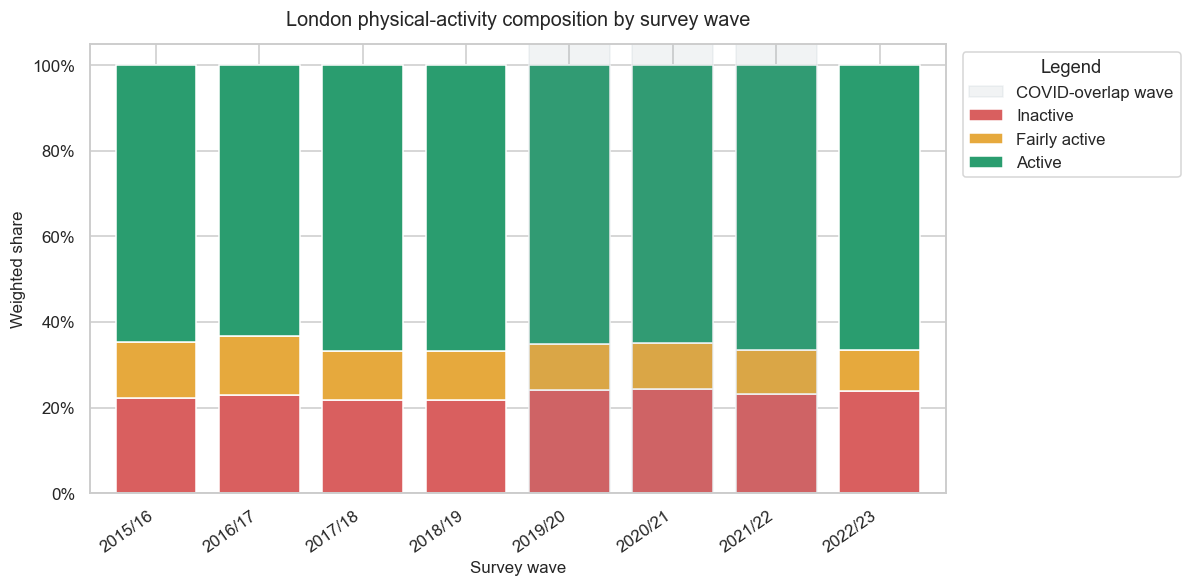

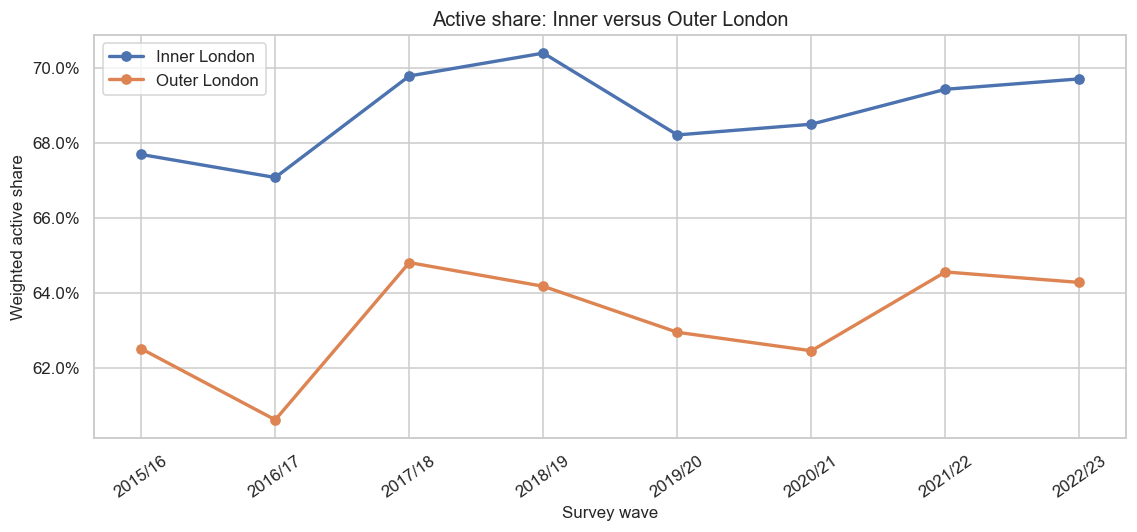

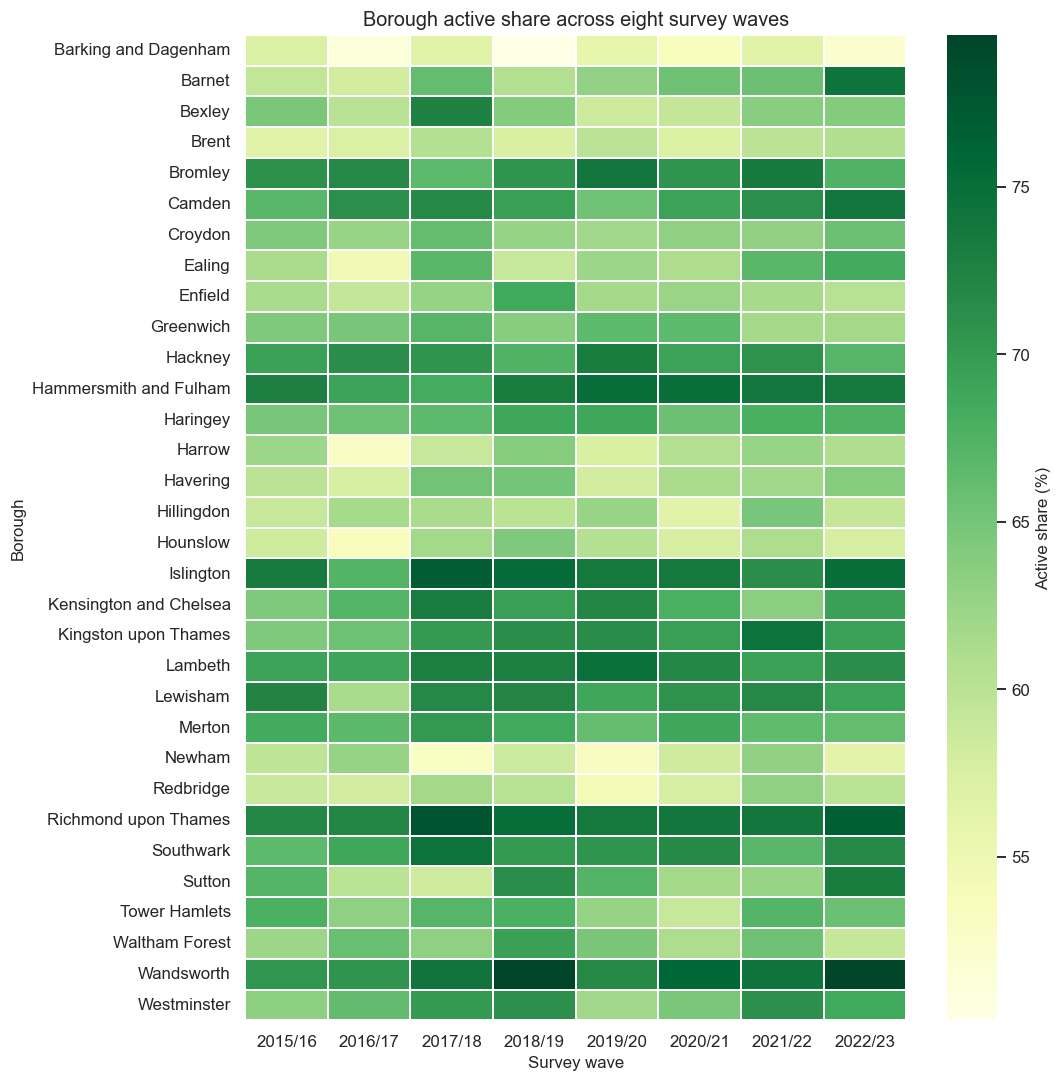

In [4]:
annual_plot = london_annual.set_index('survey_wave')[TARGETS].mul(100)
annual_plot.columns = [TARGET_LABELS[column] for column in TARGETS]
ax = annual_plot.plot(
    kind='bar', stacked=True, figsize=(11, 5.5),
    color=['#d95f5f', '#e6a93d', '#2a9d6f'], width=0.78,
)
for position, wave in enumerate(annual_plot.index):
    if wave in {'2019/20', '2020/21', '2021/22'}:
        ax.axvspan(position - .39, position + .39, color='#78909c', alpha=.10,
                   label='COVID-overlap wave' if wave == '2019/20' else None)
ax.set(xlabel='Survey wave', ylabel='Weighted share')
ax.set_title('London physical-activity composition by survey wave', pad=12)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.legend(title='Legend', loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 5))
for area_name, group in area_annual.groupby('inner_outer', sort=False):
    ax.plot(group['survey_wave'], 100 * group['active_rate'], marker='o', linewidth=2.2, label=area_name)
ax.set(title='Active share: Inner versus Outer London', xlabel='Survey wave', ylabel='Weighted active share')
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.tick_params(axis='x', rotation=35)
ax.legend()
plt.tight_layout()
plt.show()

borough_heat = borough_annual.pivot(index='geography_name', columns='survey_wave', values='active_rate')
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(100 * borough_heat, cmap='YlGn', linewidths=.15, cbar_kws={'label': 'Active share (%)'}, ax=ax)
ax.set(title='Borough active share across eight survey waves', xlabel='Survey wave', ylabel='Borough')
plt.tight_layout()
plt.show()

## 4. Simple monthly visualisations

These charts use the monthly panels, which were constructed with `wt_time`. Raw monthly estimates are shown lightly; a three-month trailing mean makes the broad direction easier to read. Grey bands use the same two COVID calendar periods later supplied to the models.

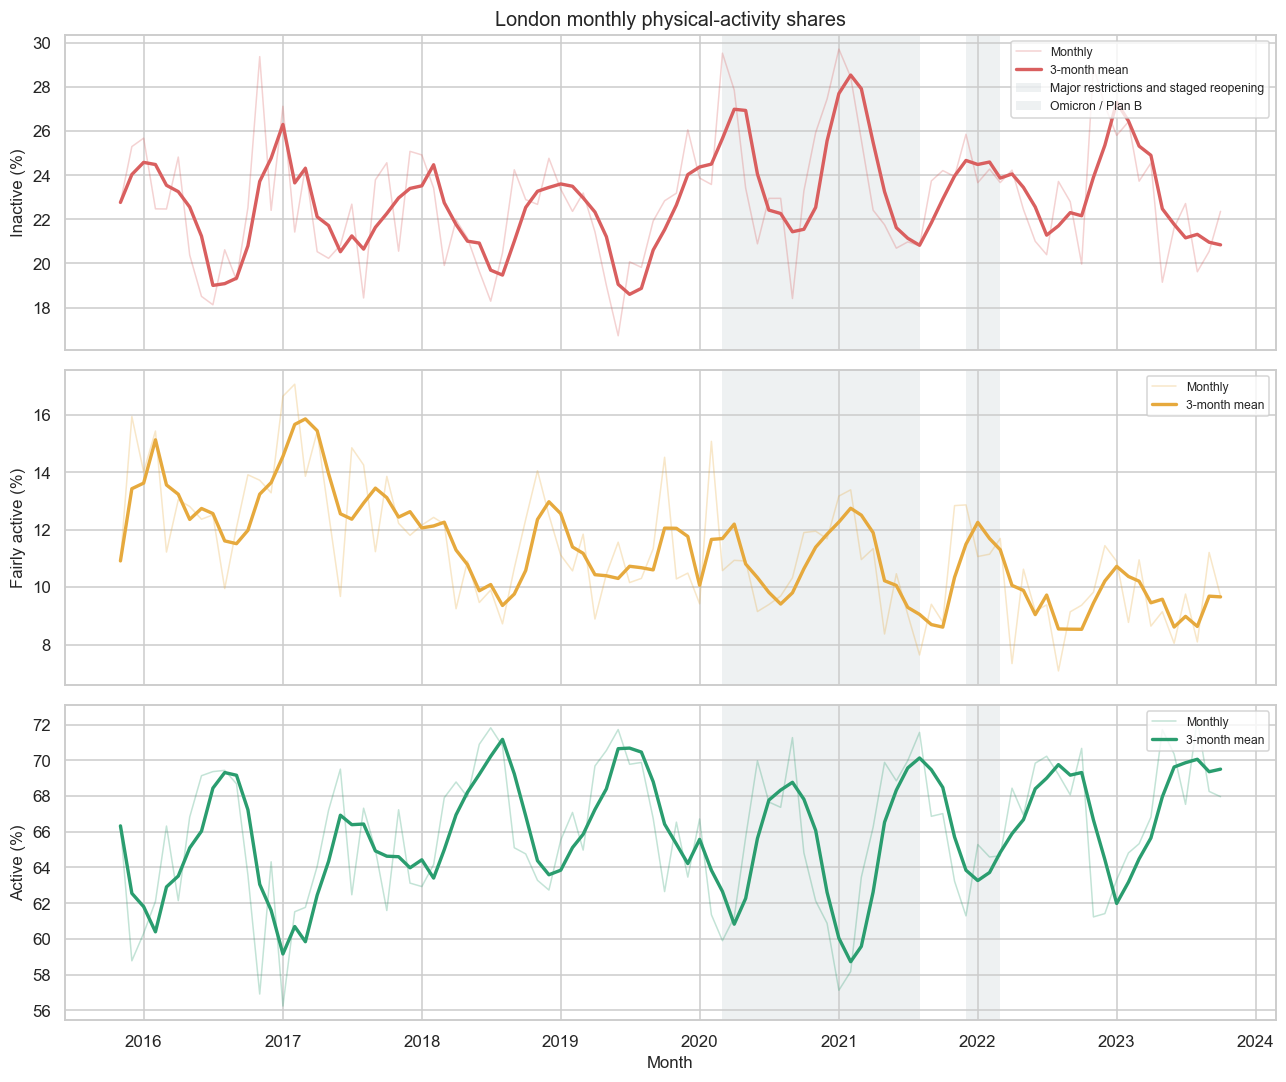

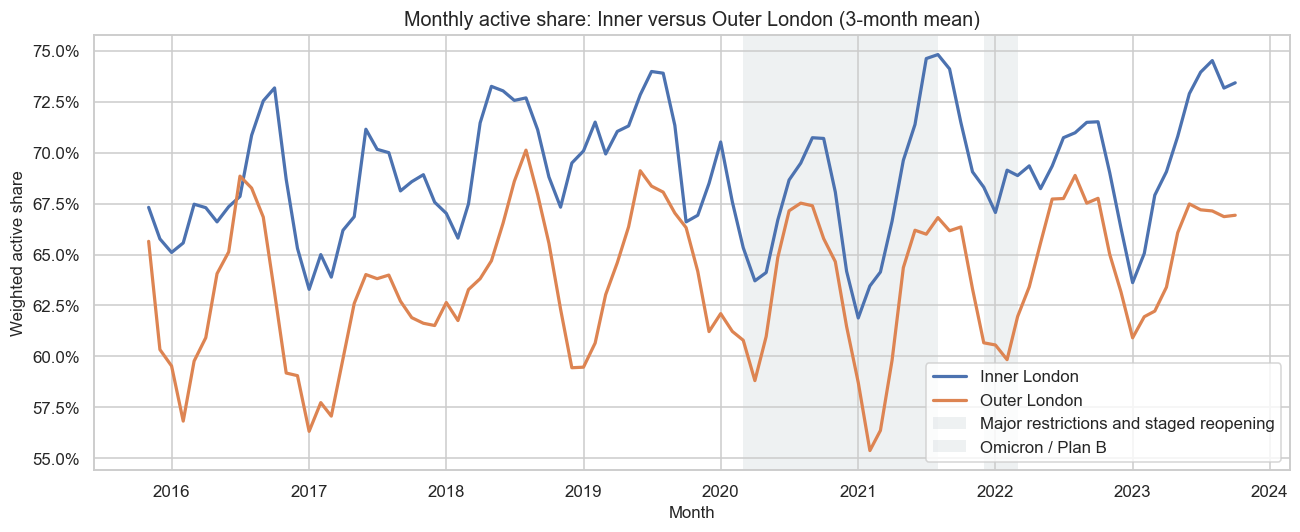

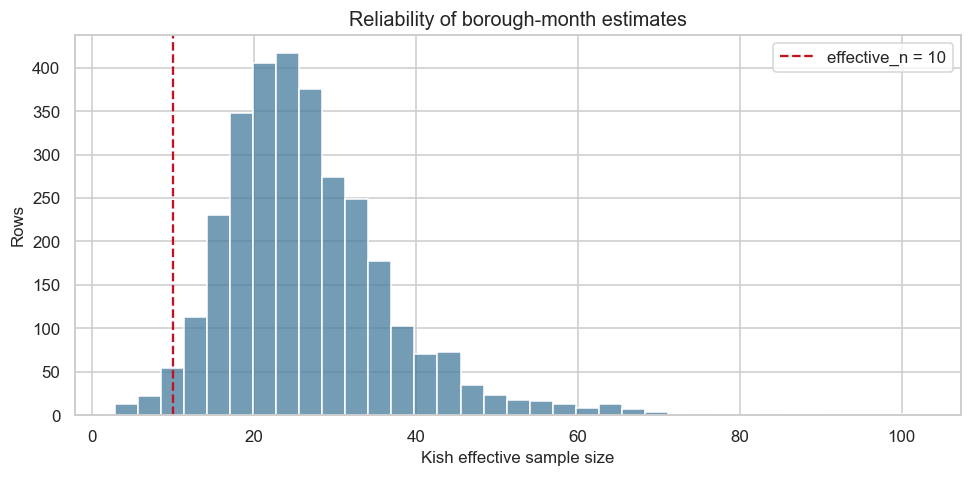

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
colors = ['#d95f5f', '#e6a93d', '#2a9d6f']
for ax, target, color in zip(axes, TARGETS, colors):
    raw = 100 * london_monthly[target]
    smooth = raw.rolling(3, min_periods=1).mean()
    ax.plot(london_monthly['period_start'], raw, color=color, alpha=.28, linewidth=1, label='Monthly')
    ax.plot(london_monthly['period_start'], smooth, color=color, linewidth=2.2, label='3-month mean')
    shade_covid_periods(ax, show_labels=(target == TARGETS[0]))
    ax.set_ylabel(TARGET_LABELS[target] + ' (%)')
    ax.legend(loc='upper right', fontsize=8)
axes[0].set_title('London monthly physical-activity shares')
axes[-1].set_xlabel('Month')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for area_name, group in area_monthly.groupby('inner_outer', sort=False):
    group = group.sort_values('month_index')
    smooth = group['active_rate'].rolling(3, min_periods=1).mean()
    ax.plot(group['period_start'], 100 * smooth, linewidth=2.1, label=area_name)
shade_covid_periods(ax, show_labels=True)
ax.set(title='Monthly active share: Inner versus Outer London (3-month mean)',
       xlabel='Month', ylabel='Weighted active share')
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(borough_monthly['effective_n'].dropna(), bins=35, color='#457b9d', ax=ax)
ax.axvline(10, color='#c1121f', linestyle='--', label='effective_n = 10')
ax.set(title='Reliability of borough-month estimates', xlabel='Kish effective sample size', ylabel='Rows')
ax.legend()
plt.tight_layout()
plt.show()

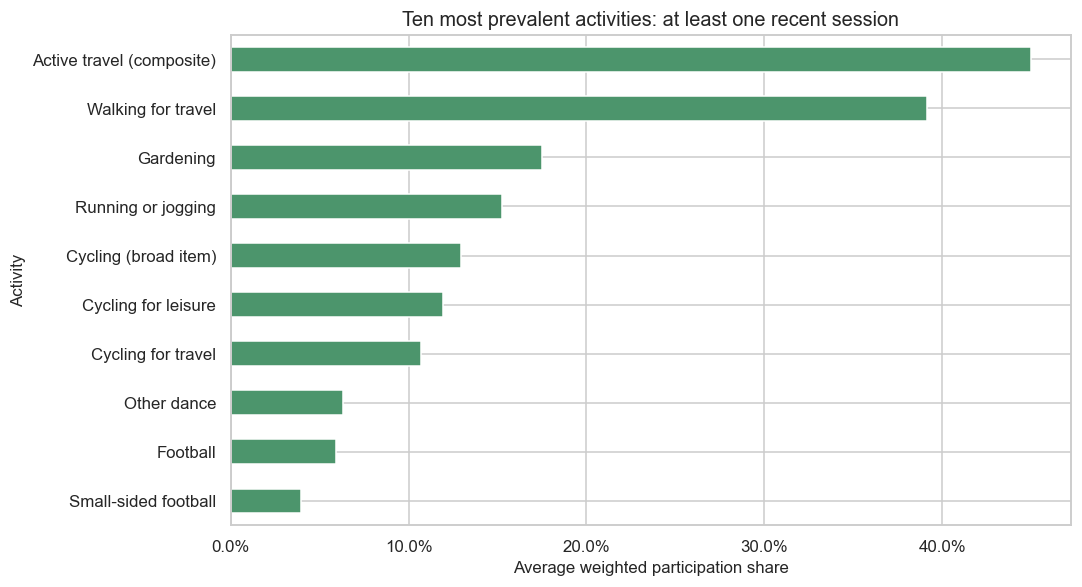

,average_percent
Small-sided football,3.941733
Football,5.915903
Other dance,6.344941
Cycling for travel,10.692553
Cycling for leisure,11.927517
Cycling (broad item),12.933007
Running or jogging,15.264698
Gardening,17.483264
Walking for travel,39.155530
Active travel (composite),44.997503


In [6]:
days_any_columns = [column for column in activity_columns if column.startswith('DAYS_ANY_RATE_')]
top_activity_columns = london_monthly[days_any_columns].mean().nlargest(10).index
READABLE_ACTIVITY_LABELS = {
    'ACTTRAV_C03': 'Active travel (composite)',
    'WALKTRAV_B02': 'Walking for travel',
    'GARD_B08': 'Gardening',
    'RUNJOG_U07': 'Running or jogging',
    'CYC_OLD_M02': 'Cycling (broad item)',
    'CYCLEISURE_N01': 'Cycling for leisure',
    'CYCTRAV_B04': 'Cycling for travel',
    'DANCEOTHER_O01': 'Other dance',
    'FOOTBALL_F01': 'Football',
    'FOOTBALLSMALL_Q02': 'Small-sided football',
}
top_activities = (
    london_monthly[top_activity_columns].mean().mul(100)
    .rename(lambda column: READABLE_ACTIVITY_LABELS.get(
        column.removeprefix('DAYS_ANY_RATE_'),
        column.removeprefix('DAYS_ANY_RATE_').replace('_', ' ').title(),
    ))
    .sort_values()
)
fig, ax = plt.subplots(figsize=(10, 5.5))
top_activities.plot(kind='barh', color='#4c956c', ax=ax)
ax.set(title='Ten most prevalent activities: at least one recent session',
       xlabel='Average weighted participation share', ylabel='Activity')
ax.xaxis.set_major_formatter(PercentFormatter(100))
plt.tight_layout()
plt.show()
display(top_activities.rename('average_percent').to_frame())

## 5. Forecast design

The borough-month panel is used for modelling because it supplies 32 parallel geographic series. London and Inner/Outer panels remain descriptive checks and are not mixed into training.

- **Forecast origin:** October 2022.
- **Independent test year:** November 2022 to October 2023 (`month_index` 85–96).
- **Forecast horizon:** all 12 months are predicted using only the same month one year earlier (`lag12`) plus known calendar/geography fields.
- **Development validation:** three expanding, 12-month time blocks. All boroughs from a month stay in the same fold.
- **Targets:** the three shares are transformed to two additive log-ratio coordinates and converted back with a softmax. Predictions are therefore non-negative and sum exactly to one.
- **COVID handling:** a pre-defined `covid_restriction_flag` marks whether the forecasted month lies in March 2020–July 2021 or December 2021–February 2022. A second `covid_lag12_source_flag` marks whether the prior-year inputs came from one of those periods. Both are known from the calendar, not derived from the target. COVID and non-COVID validation errors are reported separately.
- **Final test interpretation:** November 2022–October 2023 is after the two defined restriction periods, so it tests post-restriction outcomes. However, December 2022–February 2023 use lag-12 survey inputs observed during Omicron/Plan B; the second flag makes that inherited exposure explicit rather than claiming the test information is wholly COVID-free.
- **Missing cell:** the genuine Barking and Dagenham October 2020 row and its completely missing lagged counterpart are excluded from supervised fitting, never filled with zero.

In [7]:
panel = borough_monthly.sort_values(['geography_code', 'month_index']).reset_index(drop=True).copy()
source_lag_columns = TARGETS + COMPOSITION_FEATURES + activity_columns
grouped = panel.groupby('geography_code', sort=False)

engineered = {
    'trend': panel['month_index'].astype(float),
    'month_sin': np.sin(2 * np.pi * (panel['month_of_wave'] - 1) / 12),
    'month_cos': np.cos(2 * np.pi * (panel['month_of_wave'] - 1) / 12),
    'covid_restriction_flag': covid_restriction_flag(panel['period_start']),
    'covid_lag12_source_flag': covid_restriction_flag(
        panel['period_start'] - pd.DateOffset(years=1)
    ),
}
for column in source_lag_columns:
    engineered[f'{column}_lag12'] = grouped[column].shift(12)

engineered_frame = pd.DataFrame(engineered, index=panel.index)
model_panel = pd.concat([panel, engineered_frame], axis=1)
lagged_source_features = [f'{column}_lag12' for column in source_lag_columns]
model_panel['lag_missing_fraction'] = model_panel[lagged_source_features].isna().mean(axis=1)

numeric_features = [
    'trend', 'month_sin', 'month_cos',
    'covid_restriction_flag', 'covid_lag12_source_flag',
] + lagged_source_features
categorical_features = ['geography_name']
model_features = numeric_features + categorical_features

supervised = model_panel.loc[
    model_panel['month_index'].ge(13)
    & model_panel[TARGETS].notna().all(axis=1)
    & model_panel['lag_missing_fraction'].lt(.95)
].copy()

development = supervised.loc[supervised['month_index'].lt(TEST_START_MONTH)].copy()
holdout = supervised.loc[supervised['month_index'].between(TEST_START_MONTH, TEST_END_MONTH)].copy()

assert development['month_index'].max() == 84
assert holdout['month_index'].min() == 85 and holdout['month_index'].max() == 96
assert len(holdout) == 12 * 32
assert not any(column in model_features for column in TARGETS + COMPOSITION_FEATURES + activity_columns)
assert all(column.endswith('_lag12') for column in lagged_source_features)
assert holdout['covid_restriction_flag'].eq(0).all()
assert development['covid_restriction_flag'].eq(1).any()
assert int(holdout['covid_lag12_source_flag'].sum()) == 3 * 32

CV_BLOCKS = [
    {'fold': 1, 'train_end': 48, 'valid_start': 49, 'valid_end': 60},
    {'fold': 2, 'train_end': 60, 'valid_start': 61, 'valid_end': 72},
    {'fold': 3, 'train_end': 72, 'valid_start': 73, 'valid_end': 84},
]
split_summary = []
for block in CV_BLOCKS:
    train_rows = supervised['month_index'].le(block['train_end'])
    valid_rows = supervised['month_index'].between(block['valid_start'], block['valid_end'])
    split_summary.append({
        **block,
        'training rows': int(train_rows.sum()),
        'validation rows': int(valid_rows.sum()),
    })
split_summary.append({
    'fold': 'final test', 'train_end': 84, 'valid_start': 85, 'valid_end': 96,
    'training rows': len(development), 'validation rows': len(holdout),
})
display(pd.DataFrame(split_summary))
print(f'Model inputs: {len(numeric_features)} numeric fields + borough identity.')
print(f'Development rows: {len(development):,}; untouched test rows: {len(holdout):,}.')
print(f"COVID-flagged development rows: {int(development['covid_restriction_flag'].sum()):,}; "
      'COVID-flagged final-test target rows: 0.')
print('Final-test rows whose lag-12 inputs came from Omicron / Plan B: 96 (3 months × 32 boroughs).')

,fold,train_end,valid_start,valid_end,training rows,validation rows
0,1,48,49,60,1152,383
1,2,60,61,72,1535,383
2,3,72,73,84,1918,384
3,final test,84,85,96,2302,384


Model inputs: 383 numeric fields + borough identity.
Development rows: 2,302; untouched test rows: 384.
COVID-flagged development rows: 639; COVID-flagged final-test target rows: 0.
Final-test rows whose lag-12 inputs came from Omicron / Plan B: 96 (3 months × 32 boroughs).


## 6. Models, coherent-share transformation and metrics

The four methods answer the forecasting question differently:

- **Seasonal naive:** copies the same borough's three observed shares from 12 months earlier. It is a required benchmark, not a learned model.
- **Ridge:** fits a regularised linear relationship in two additive log-ratio coordinates. L2 shrinkage stabilises the many correlated lagged activity variables; the penalty is selected using development folds only.
- **Random Forest:** averages many bootstrap regression trees. It can learn nonlinearities and interactions without specifying them, while minimum leaf size and feature subsampling limit variance.
- **Gradient Boosting:** adds shallow trees sequentially so that each tree corrects residual errors left by earlier trees. Huber loss, a low learning rate and shallow depth make it less sensitive to noisy borough-month estimates.

Ridge is the transparent primary reference. The tree models are less transparent, so they must pass temporal validation plus out-of-bag/generalisation, permutation-importance and residual diagnostics. All learned models see the same lag-12 survey features, borough/calendar fields and COVID calendar flag.

The primary error is total-variation distance: half the sum of absolute errors across the three shares. It is reported with and without `effective_n` weighting. Per-target MAE, RMSE and R² are secondary diagnostics.

In [8]:
def shares_to_alr(shares, epsilon=ALR_EPSILON):
    values = np.asarray(shares, dtype=float)
    values = np.clip(values, epsilon, None)
    values = values / values.sum(axis=1, keepdims=True)
    return np.column_stack([
        np.log(values[:, 0] / values[:, 2]),
        np.log(values[:, 1] / values[:, 2]),
    ])


def alr_to_shares(coordinates):
    coordinates = np.asarray(coordinates, dtype=float)
    logits = np.column_stack([coordinates[:, 0], coordinates[:, 1], np.zeros(len(coordinates))])
    logits = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)


def normalised_fit_weights(weights):
    values = np.asarray(weights, dtype=float)
    low, high = np.quantile(values, [.05, .95])
    values = np.clip(values, low, high)
    return values / values.mean()


def composition_metrics(actual, predicted, weights):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    weights = np.asarray(weights, dtype=float)
    absolute = np.abs(actual - predicted)
    squared = np.square(actual - predicted)
    row_tv = .5 * absolute.sum(axis=1)
    result = {
        'weighted_tv': float(np.average(row_tv, weights=weights)),
        'unweighted_tv': float(row_tv.mean()),
    }
    for index, target in enumerate(TARGETS):
        result[f'{target}_mae'] = float(np.average(absolute[:, index], weights=weights))
        result[f'{target}_rmse'] = float(np.sqrt(np.average(squared[:, index], weights=weights)))
        result[f'{target}_r2'] = float(r2_score(actual[:, index], predicted[:, index], sample_weight=weights))
    return result


def make_preprocessor(scale_numeric):
    numeric_steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('variance', VarianceThreshold(threshold=1e-10)),
    ]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), numeric_features),
        ('borough', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ])


def make_ridge(alpha):
    return Pipeline([
        ('preprocessor', make_preprocessor(scale_numeric=True)),
        ('model', Ridge(alpha=alpha)),
    ])


def make_random_forest():
    return Pipeline([
        ('preprocessor', make_preprocessor(scale_numeric=False)),
        ('model', RandomForestRegressor(
            n_estimators=300, min_samples_leaf=5, max_features=.40,
            oob_score=True, n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ])


def make_gradient_boosting():
    base = GradientBoostingRegressor(
        n_estimators=140, learning_rate=.03, max_depth=2,
        min_samples_leaf=10, loss='huber', random_state=RANDOM_STATE,
    )
    return Pipeline([
        ('preprocessor', make_preprocessor(scale_numeric=False)),
        ('model', MultiOutputRegressor(base, n_jobs=-1)),
    ])


def seasonal_naive(frame):
    prediction = frame[[f'{target}_lag12' for target in TARGETS]].to_numpy(float)
    assert np.isfinite(prediction).all()
    return prediction / prediction.sum(axis=1, keepdims=True)


def run_temporal_cv(model_name, estimator=None):
    fold_metrics = []
    prediction_parts = []
    for block in CV_BLOCKS:
        train = supervised.loc[supervised['month_index'].le(block['train_end'])]
        valid = supervised.loc[supervised['month_index'].between(block['valid_start'], block['valid_end'])]
        actual = valid[TARGETS].to_numpy(float)

        if estimator is None:
            predicted = seasonal_naive(valid)
        else:
            fitted = clone(estimator)
            fitted.fit(
                train[model_features], shares_to_alr(train[TARGETS]),
                model__sample_weight=normalised_fit_weights(train['effective_n']),
            )
            predicted = alr_to_shares(fitted.predict(valid[model_features]))

        metrics = composition_metrics(actual, predicted, valid['effective_n'])
        fold_metrics.append({'model': model_name, 'fold': block['fold'], **metrics})

        part = valid[['month_index', 'period_start', 'geography_code', 'geography_name', 'effective_n']].copy()
        part['fold'] = block['fold']
        for index, target in enumerate(TARGETS):
            part[f'actual_{target}'] = actual[:, index]
            part[f'predicted_{target}'] = predicted[:, index]
        prediction_parts.append(part)
    return pd.DataFrame(fold_metrics), pd.concat(prediction_parts, ignore_index=True)

## 7. Expanding-window cross-validation and model selection

Ridge strength is tuned only inside the development period. Tree-model settings are deliberately conservative to limit overfitting. The final model is chosen from mean cross-validation error before the last year is opened. If Ridge lies within one standard error of the lowest-error model, Ridge is preferred for transparency.

In [9]:
cv_fold_results = {}
cv_predictions = {}

naive_metrics, naive_predictions = run_temporal_cv('Seasonal naive')
cv_fold_results['Seasonal naive'] = naive_metrics
cv_predictions['Seasonal naive'] = naive_predictions

ridge_tuning_rows = []
ridge_candidate_results = {}
for alpha in [1.0, 10.0, 100.0, 1000.0]:
    metrics, predictions = run_temporal_cv(f'Ridge alpha={alpha:g}', make_ridge(alpha))
    ridge_candidate_results[alpha] = (metrics, predictions)
    ridge_tuning_rows.append({
        'alpha': alpha,
        'mean weighted TV': metrics['weighted_tv'].mean(),
        'standard deviation': metrics['weighted_tv'].std(ddof=1),
    })
ridge_tuning = pd.DataFrame(ridge_tuning_rows).sort_values('mean weighted TV')
BEST_RIDGE_ALPHA = float(ridge_tuning.iloc[0]['alpha'])
ridge_metrics, ridge_predictions = ridge_candidate_results[BEST_RIDGE_ALPHA]
ridge_metrics = ridge_metrics.assign(model='Ridge')
cv_fold_results['Ridge'] = ridge_metrics
cv_predictions['Ridge'] = ridge_predictions

forest_metrics, forest_predictions = run_temporal_cv('Random Forest', make_random_forest())
boost_metrics, boost_predictions = run_temporal_cv('Gradient Boosting', make_gradient_boosting())
cv_fold_results['Random Forest'] = forest_metrics
cv_predictions['Random Forest'] = forest_predictions
cv_fold_results['Gradient Boosting'] = boost_metrics
cv_predictions['Gradient Boosting'] = boost_predictions

all_cv_metrics = pd.concat(cv_fold_results.values(), ignore_index=True)
cv_comparison = (
    all_cv_metrics.groupby('model', as_index=False)
    .agg(
        mean_weighted_tv=('weighted_tv', 'mean'),
        sd_weighted_tv=('weighted_tv', 'std'),
        mean_unweighted_tv=('unweighted_tv', 'mean'),
    )
    .sort_values('mean_weighted_tv')
)
cv_comparison['standard_error'] = cv_comparison['sd_weighted_tv'] / np.sqrt(len(CV_BLOCKS))

best_row = cv_comparison.iloc[0]
one_se_limit = best_row['mean_weighted_tv'] + best_row['standard_error']
eligible = set(cv_comparison.loc[cv_comparison['mean_weighted_tv'].le(one_se_limit), 'model'])
priority = ['Seasonal naive', 'Ridge', 'Random Forest', 'Gradient Boosting']
SELECTED_MODEL = next(model for model in priority if model in eligible)

display(ridge_tuning.style.format({
    'mean weighted TV': '{:.4f}', 'standard deviation': '{:.4f}'
}))
display(cv_comparison.style.format({
    'mean_weighted_tv': '{:.4f}', 'sd_weighted_tv': '{:.4f}',
    'mean_unweighted_tv': '{:.4f}', 'standard_error': '{:.4f}',
}))
print(f'Ridge alpha selected inside development data: {BEST_RIDGE_ALPHA:g}')
print(f'Model selected before opening the test year: {SELECTED_MODEL}')

,alpha,mean weighted TV,standard deviation
3,1000.000000,0.1078,0.0056
2,100.000000,0.1130,0.0070
1,10.000000,0.1189,0.0088
0,1.000000,0.1238,0.0090


,model,mean_weighted_tv,sd_weighted_tv,mean_unweighted_tv,standard_error
0,Gradient Boosting,0.1041,0.0045,0.1098,0.0026
2,Ridge,0.1078,0.0056,0.1128,0.0033
1,Random Forest,0.1118,0.0134,0.1163,0.0077
3,Seasonal naive,0.1429,0.0051,0.1476,0.0030


Ridge alpha selected inside development data: 1000
Model selected before opening the test year: Gradient Boosting


## 8. Fit on all development months and evaluate the final year once

All model choices are now fixed. The following cell fits on months 13–84 and evaluates months 85–96. Confidence intervals for total-variation error use a month-block bootstrap, recognising that 384 borough rows represent only 12 independent time periods.

In [10]:
model_templates = {
    'Ridge': make_ridge(BEST_RIDGE_ALPHA),
    'Random Forest': make_random_forest(),
    'Gradient Boosting': make_gradient_boosting(),
}
fitted_models = {}
test_predictions = {'Seasonal naive': seasonal_naive(holdout)}
train_predictions = {'Seasonal naive': seasonal_naive(development)}

fit_start = time.time()
for model_name, template in model_templates.items():
    fitted = clone(template)
    fitted.fit(
        development[model_features], shares_to_alr(development[TARGETS]),
        model__sample_weight=normalised_fit_weights(development['effective_n']),
    )
    fitted_models[model_name] = fitted
    test_predictions[model_name] = alr_to_shares(fitted.predict(holdout[model_features]))
    train_predictions[model_name] = alr_to_shares(fitted.predict(development[model_features]))
print(f'Final models fitted in {time.time() - fit_start:.1f} seconds.')


def month_block_interval(frame, predicted, repeats=1000):
    rng = np.random.default_rng(RANDOM_STATE)
    months = np.sort(frame['month_index'].unique())
    actual = frame[TARGETS].to_numpy(float)
    weights = frame['effective_n'].to_numpy(float)
    month_values = frame['month_index'].to_numpy()
    estimates = []
    for _ in range(repeats):
        sampled_months = rng.choice(months, size=len(months), replace=True)
        indices = np.concatenate([np.flatnonzero(month_values == month) for month in sampled_months])
        estimates.append(composition_metrics(actual[indices], predicted[indices], weights[indices])['weighted_tv'])
    return np.quantile(estimates, [.025, .975])


test_metric_rows = []
generalisation_rows = []
actual_test = holdout[TARGETS].to_numpy(float)
actual_train = development[TARGETS].to_numpy(float)
for model_name, predicted in test_predictions.items():
    metrics = composition_metrics(actual_test, predicted, holdout['effective_n'])
    low, high = month_block_interval(holdout, predicted)
    test_metric_rows.append({
        'model': model_name, **metrics,
        'weighted_tv_ci_low': low, 'weighted_tv_ci_high': high,
    })
    train_metric = composition_metrics(actual_train, train_predictions[model_name], development['effective_n'])
    generalisation_rows.append({
        'model': model_name,
        'training weighted TV': train_metric['weighted_tv'],
        'test weighted TV': metrics['weighted_tv'],
        'test/train ratio': metrics['weighted_tv'] / train_metric['weighted_tv'],
    })

test_metrics = pd.DataFrame(test_metric_rows).sort_values('weighted_tv')
naive_test_error = test_metrics.loc[test_metrics['model'].eq('Seasonal naive'), 'weighted_tv'].iloc[0]
test_metrics['skill_vs_seasonal'] = 1 - test_metrics['weighted_tv'] / naive_test_error
generalisation = pd.DataFrame(generalisation_rows).sort_values('test weighted TV')

display(test_metrics[[
    'model', 'weighted_tv', 'weighted_tv_ci_low', 'weighted_tv_ci_high',
    'unweighted_tv', 'skill_vs_seasonal',
]].style.format({column: '{:.4f}' for column in [
    'weighted_tv', 'weighted_tv_ci_low', 'weighted_tv_ci_high',
    'unweighted_tv', 'skill_vs_seasonal',
]}))
display(generalisation.style.format({
    'training weighted TV': '{:.4f}', 'test weighted TV': '{:.4f}', 'test/train ratio': '{:.2f}'
}))

prediction_output = holdout[[
    'month_index', 'period_start', 'geography_code', 'geography_name', 'inner_outer', 'effective_n'
]].reset_index(drop=True).copy()
for index, target in enumerate(TARGETS):
    prediction_output[f'actual_{target}'] = actual_test[:, index]
for model_name, predicted in test_predictions.items():
    safe_name = model_name.lower().replace(' ', '_')
    for index, target in enumerate(TARGETS):
        prediction_output[f'{safe_name}_{target}'] = predicted[:, index]

all_cv_metrics.to_csv(OUTPUT_DIR / 'monthly_forecast_cv_fold_metrics.csv', index=False, encoding='utf-8-sig')
cv_comparison.to_csv(OUTPUT_DIR / 'monthly_forecast_cv_metrics.csv', index=False, encoding='utf-8-sig')
test_metrics.to_csv(OUTPUT_DIR / 'monthly_forecast_test_metrics.csv', index=False, encoding='utf-8-sig')
prediction_output.to_csv(OUTPUT_DIR / 'monthly_forecast_holdout_predictions.csv', index=False, encoding='utf-8-sig')

Final models fitted in 8.1 seconds.


,model,weighted_tv,weighted_tv_ci_low,weighted_tv_ci_high,unweighted_tv,skill_vs_seasonal
3,Gradient Boosting,0.1023,0.0950,0.1101,0.1048,0.2663
1,Ridge,0.1046,0.0965,0.1122,0.1072,0.2500
2,Random Forest,0.1062,0.0983,0.1147,0.1084,0.2386
0,Seasonal naive,0.1394,0.1272,0.1543,0.1439,0.0000


,model,training weighted TV,test weighted TV,test/train ratio
3,Gradient Boosting,0.0959,0.1023,1.07
1,Ridge,0.0969,0.1046,1.08
2,Random Forest,0.0674,0.1062,1.58
0,Seasonal naive,0.1413,0.1394,0.99


In [11]:
target_metric_rows = []
for _, row in test_metrics.iterrows():
    for target in TARGETS:
        target_metric_rows.append({
            'model': row['model'],
            'target': TARGET_LABELS[target],
            'weighted MAE': row[f'{target}_mae'],
            'weighted RMSE': row[f'{target}_rmse'],
            'weighted R2': row[f'{target}_r2'],
        })
target_metrics = pd.DataFrame(target_metric_rows)
display(target_metrics.pivot(index='model', columns='target', values='weighted MAE').style.format('{:.2%}'))
display(target_metrics.pivot(index='model', columns='target', values='weighted R2').style.format('{:.3f}'))
target_metrics.to_csv(OUTPUT_DIR / 'monthly_forecast_test_target_metrics.csv', index=False, encoding='utf-8-sig')

target,Active,Fairly active,Inactive
model,,,
Gradient Boosting,8.42%,4.50%,7.54%
Random Forest,8.88%,4.67%,7.68%
Ridge,8.59%,4.63%,7.69%
Seasonal naive,11.26%,6.29%,10.33%


target,Active,Fairly active,Inactive
model,,,
Gradient Boosting,0.169,0.001,0.155
Random Forest,0.061,-0.156,0.113
Ridge,0.136,-0.088,0.118
Seasonal naive,-0.485,-0.986,-0.559


## 9. Test-year forecast plots and uncertainty

The monthly trajectory below is an `effective_n`-weighted summary of the 32 borough predictions, not a replacement for the separately survey-weighted London panel.

,target,nominal interval,weighted empirical coverage,average interval width
0,Inactive,90%,92.4%,33.2%
1,Fairly active,90%,92.5%,19.1%
2,Active,90%,94.4%,37.8%


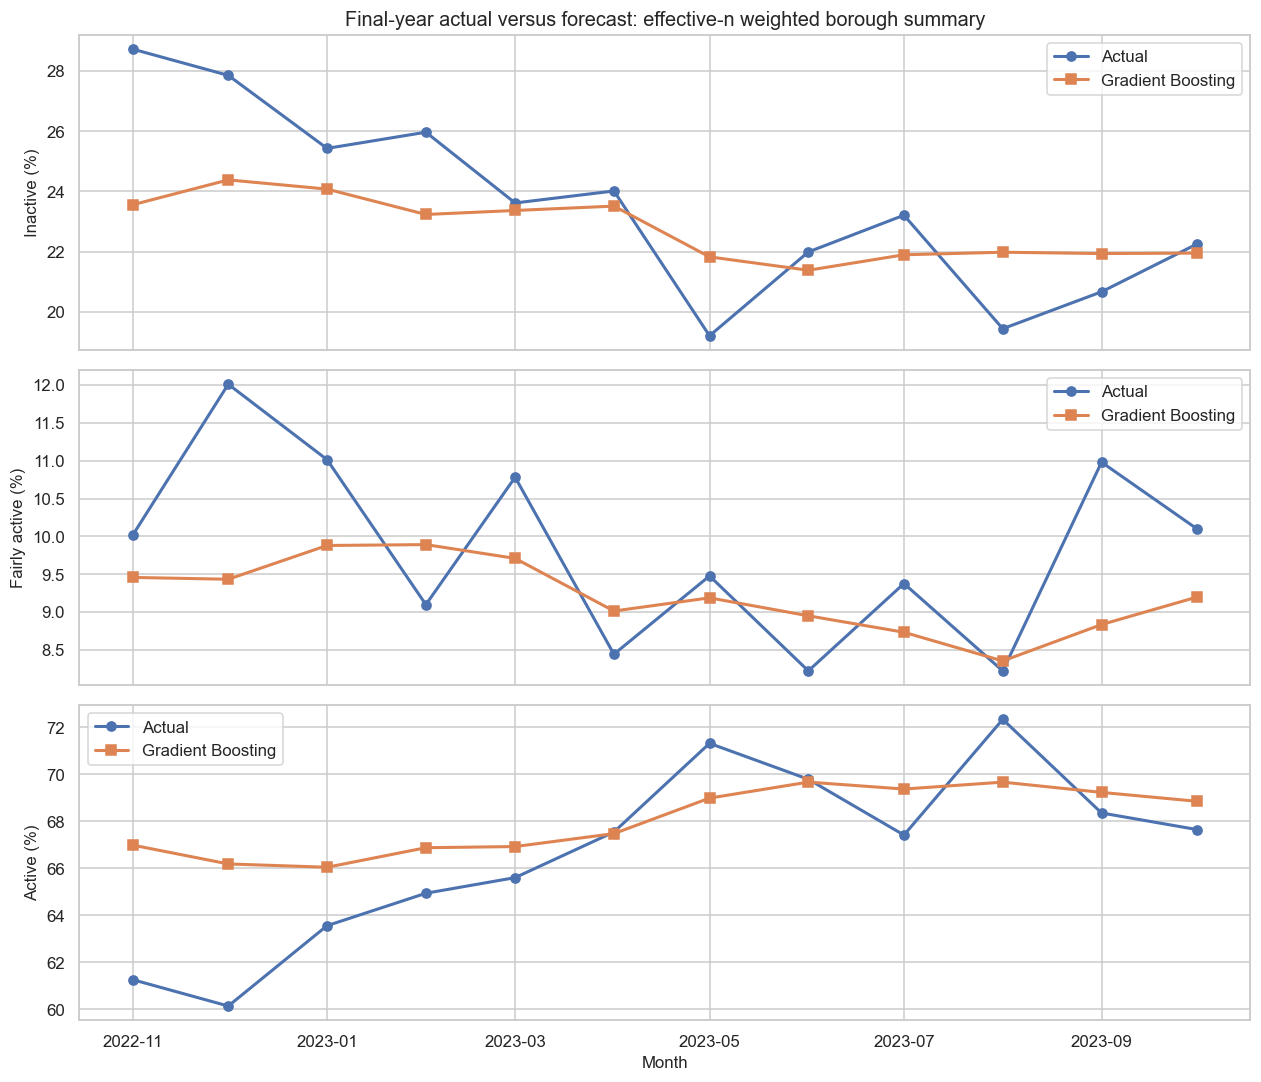

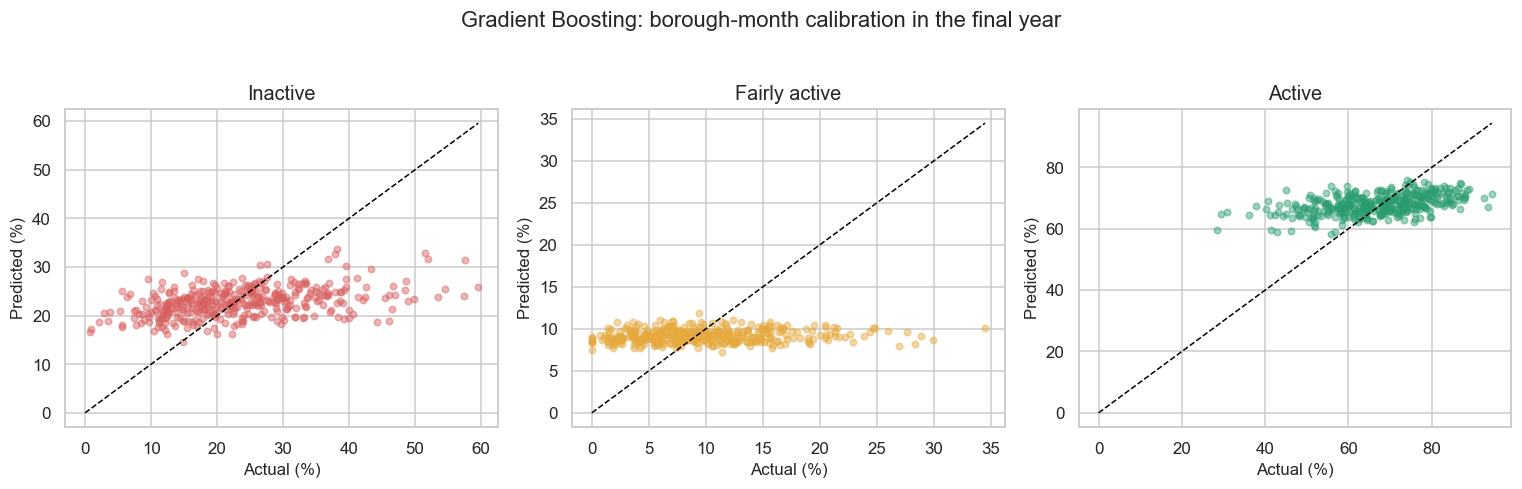

In [12]:
selected_predictions = test_predictions[SELECTED_MODEL]
selected_safe_name = SELECTED_MODEL.lower().replace(' ', '_')

cv_selected = cv_predictions[SELECTED_MODEL]
residual_quantiles = {}
for target in TARGETS:
    residual_quantiles[target] = np.quantile(
        np.abs(cv_selected[f'actual_{target}'] - cv_selected[f'predicted_{target}']), .90
    )

coverage_rows = []
for index, target in enumerate(TARGETS):
    radius = residual_quantiles[target]
    lower = np.clip(selected_predictions[:, index] - radius, 0, 1)
    upper = np.clip(selected_predictions[:, index] + radius, 0, 1)
    prediction_output[f'{selected_safe_name}_{target}_p05'] = lower
    prediction_output[f'{selected_safe_name}_{target}_p95'] = upper
    covered = (actual_test[:, index] >= lower) & (actual_test[:, index] <= upper)
    coverage_rows.append({
        'target': TARGET_LABELS[target],
        'nominal interval': '90%',
        'weighted empirical coverage': np.average(covered, weights=holdout['effective_n']),
        'average interval width': np.average(upper - lower, weights=holdout['effective_n']),
    })
prediction_output.to_csv(OUTPUT_DIR / 'monthly_forecast_holdout_predictions.csv', index=False, encoding='utf-8-sig')
coverage_summary = pd.DataFrame(coverage_rows)
coverage_summary.to_csv(OUTPUT_DIR / 'monthly_forecast_interval_coverage.csv', index=False, encoding='utf-8-sig')
display(coverage_summary.style.format({
    'weighted empirical coverage': '{:.1%}', 'average interval width': '{:.1%}'
}))


def weighted_monthly_series(frame, actual, predicted, target_index):
    rows = []
    for month, positions in frame.groupby('month_index').indices.items():
        positions = np.asarray(positions)
        weights = frame.iloc[positions]['effective_n'].to_numpy(float)
        rows.append({
            'month_index': month,
            'period_start': frame.iloc[positions]['period_start'].iloc[0],
            'actual': np.average(actual[positions, target_index], weights=weights),
            'predicted': np.average(predicted[positions, target_index], weights=weights),
        })
    return pd.DataFrame(rows).sort_values('month_index')


fig, axes = plt.subplots(3, 1, figsize=(11.5, 10), sharex=True)
for index, (ax, target) in enumerate(zip(axes, TARGETS)):
    series = weighted_monthly_series(holdout.reset_index(drop=True), actual_test, selected_predictions, index)
    ax.plot(series['period_start'], 100 * series['actual'], marker='o', linewidth=2, label='Actual')
    ax.plot(series['period_start'], 100 * series['predicted'], marker='s', linewidth=2, label=SELECTED_MODEL)
    ax.set_ylabel(TARGET_LABELS[target] + ' (%)')
    ax.legend()
axes[0].set_title('Final-year actual versus forecast: effective-n weighted borough summary')
axes[-1].set_xlabel('Month')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for index, (ax, target) in enumerate(zip(axes, TARGETS)):
    ax.scatter(100 * actual_test[:, index], 100 * selected_predictions[:, index],
               s=18, alpha=.45, color=colors[index])
    limits = [0, 100 * max(actual_test[:, index].max(), selected_predictions[:, index].max())]
    ax.plot(limits, limits, color='black', linestyle='--', linewidth=1)
    ax.set(title=TARGET_LABELS[target], xlabel='Actual (%)', ylabel='Predicted (%)')
plt.suptitle(f'{SELECTED_MODEL}: borough-month calibration in the final year', y=1.03)
plt.tight_layout()
plt.show()

## 10. Model diagnostics, transparency and sensitivity

The following checks ask whether error concentrates in particular months, boroughs, COVID periods or low-effective-sample rows. Ridge coefficients provide a transparent linear reference. Model-agnostic permutation importance is computed on a fixed test subsample for the selected non-naive model; it measures predictive dependence and must not be interpreted as causality. Because the final test year is entirely post-restriction, its COVID flag has no variation; the COVID/non-COVID comparison therefore uses only the three pre-test temporal validation blocks.

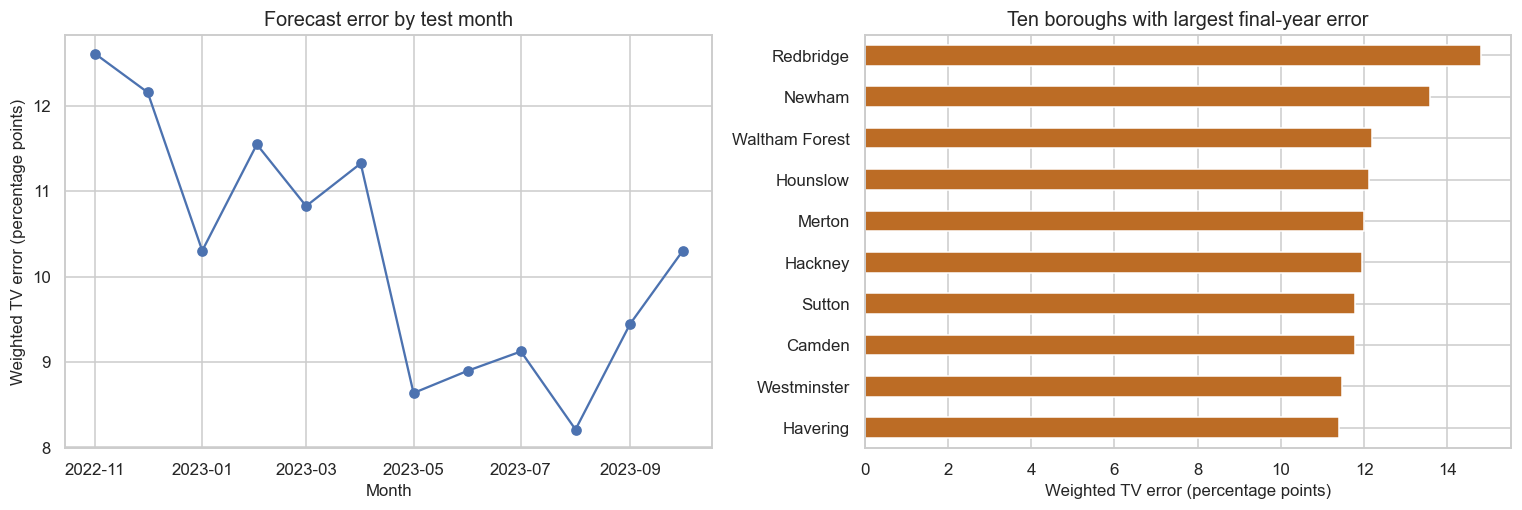

,validation period,rows,months,weighted TV,unweighted TV
0,Other period,511,16,0.0927,0.0984
1,COVID period,639,20,0.1131,0.1189


,minimum effective_n,rows retained,weighted TV,unweighted TV
0,0,384,0.1023,0.1048
1,10,381,0.1023,0.1050
2,15,365,0.1019,0.1040
3,20,307,0.1007,0.1024


,ALR epsilon,weighted TV
0,1e-06,0.1023
1,1e-04,0.1023
2,1e-03,0.1023


Coherence check passed: every selected-model prediction is in [0,1] and sums to one.
Random Forest OOB R² in ALR space: 0.051


In [13]:
diagnostic = holdout[[
    'month_index', 'period_start', 'geography_name', 'effective_n'
]].reset_index(drop=True).copy()
diagnostic['total_variation_error'] = .5 * np.abs(actual_test - selected_predictions).sum(axis=1)
diagnostic['active_residual'] = actual_test[:, 2] - selected_predictions[:, 2]

monthly_error = (
    diagnostic.groupby(['month_index', 'period_start'])
    .apply(lambda group: np.average(group['total_variation_error'], weights=group['effective_n']),
           include_groups=False)
    .rename('weighted_tv').reset_index()
)
borough_error = (
    diagnostic.groupby('geography_name')
    .apply(lambda group: np.average(group['total_variation_error'], weights=group['effective_n']),
           include_groups=False)
    .rename('weighted_tv').sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(monthly_error['period_start'], 100 * monthly_error['weighted_tv'], marker='o')
axes[0].set(title='Forecast error by test month', xlabel='Month', ylabel='Weighted TV error (percentage points)')
borough_error.tail(10).mul(100).plot(kind='barh', color='#bc6c25', ax=axes[1])
axes[1].set(title='Ten boroughs with largest final-year error', xlabel='Weighted TV error (percentage points)', ylabel='')
plt.tight_layout()
plt.show()

cv_covid = cv_selected.copy()
cv_covid['covid_period'] = np.where(
    covid_restriction_flag(cv_covid['period_start']).astype(bool), 'COVID period', 'Other period'
)
covid_metric_rows = []
for period_label, group in cv_covid.groupby('covid_period', sort=False):
    actual_columns = [f'actual_{target}' for target in TARGETS]
    predicted_columns = [f'predicted_{target}' for target in TARGETS]
    metrics = composition_metrics(group[actual_columns], group[predicted_columns], group['effective_n'])
    covid_metric_rows.append({
        'validation period': period_label,
        'rows': len(group),
        'months': group['month_index'].nunique(),
        'weighted TV': metrics['weighted_tv'],
        'unweighted TV': metrics['unweighted_tv'],
    })
covid_sensitivity = pd.DataFrame(covid_metric_rows)
display(covid_sensitivity.style.format({'weighted TV': '{:.4f}', 'unweighted TV': '{:.4f}'}))
covid_sensitivity.to_csv(
    OUTPUT_DIR / 'monthly_forecast_covid_sensitivity.csv', index=False, encoding='utf-8-sig'
)

sensitivity_rows = []
for threshold in [0, 10, 15, 20]:
    keep = holdout['effective_n'].ge(threshold).to_numpy()
    metrics = composition_metrics(actual_test[keep], selected_predictions[keep], holdout.loc[keep, 'effective_n'])
    sensitivity_rows.append({
        'minimum effective_n': threshold,
        'rows retained': int(keep.sum()),
        'weighted TV': metrics['weighted_tv'],
        'unweighted TV': metrics['unweighted_tv'],
    })
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.style.format({'weighted TV': '{:.4f}', 'unweighted TV': '{:.4f}'}))

epsilon_rows = []
for epsilon in [1e-6, ALR_EPSILON, 1e-3]:
    if SELECTED_MODEL == 'Seasonal naive':
        epsilon_prediction = seasonal_naive(holdout)
    elif np.isclose(epsilon, ALR_EPSILON):
        epsilon_prediction = selected_predictions
    else:
        epsilon_model = clone(model_templates[SELECTED_MODEL])
        epsilon_model.fit(
            development[model_features], shares_to_alr(development[TARGETS], epsilon=epsilon),
            model__sample_weight=normalised_fit_weights(development['effective_n']),
        )
        epsilon_prediction = alr_to_shares(epsilon_model.predict(holdout[model_features]))
    epsilon_metric = composition_metrics(actual_test, epsilon_prediction, holdout['effective_n'])
    epsilon_rows.append({'ALR epsilon': epsilon, 'weighted TV': epsilon_metric['weighted_tv']})
epsilon_sensitivity = pd.DataFrame(epsilon_rows)
display(epsilon_sensitivity.style.format({'ALR epsilon': '{:.0e}', 'weighted TV': '{:.4f}'}))
sensitivity.to_csv(OUTPUT_DIR / 'monthly_forecast_effective_n_sensitivity.csv', index=False, encoding='utf-8-sig')
epsilon_sensitivity.to_csv(OUTPUT_DIR / 'monthly_forecast_alr_sensitivity.csv', index=False, encoding='utf-8-sig')

assert np.allclose(selected_predictions.sum(axis=1), 1.0, atol=1e-12)
assert ((selected_predictions >= 0) & (selected_predictions <= 1)).all()
print('Coherence check passed: every selected-model prediction is in [0,1] and sums to one.')
if 'Random Forest' in fitted_models:
    print(f"Random Forest OOB R² in ALR space: {fitted_models['Random Forest'].named_steps['model'].oob_score_:.3f}")

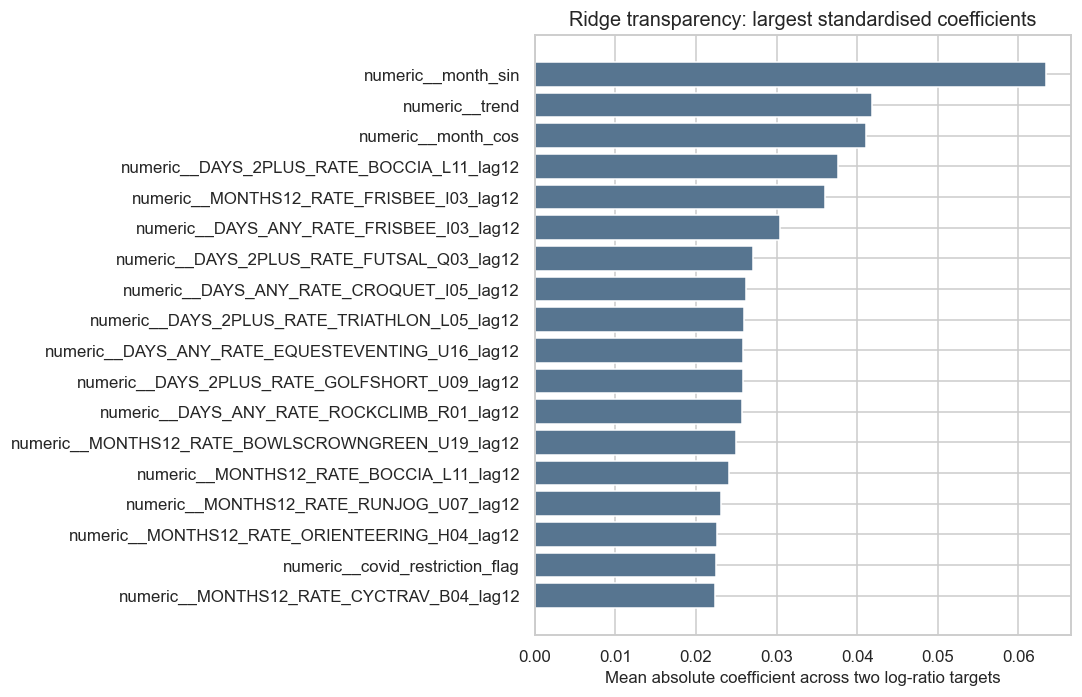

,feature,inactive_vs_active,fairly_vs_active,mean_abs_coefficient
1,numeric__month_sin,0.049572,0.077219,0.063395
0,numeric__trend,-0.008406,-0.075257,0.041831
2,numeric__month_cos,0.037244,0.045022,0.041133
312,numeric__DAYS_2PLUS_RATE_BOCCIA_L11_lag12,0.004255,-0.070993,0.037624
46,numeric__MONTHS12_RATE_FRISBEE_I03_lag12,-0.011869,-0.060224,0.036046
169,numeric__DAYS_ANY_RATE_FRISBEE_I03_lag12,0.016548,0.044288,0.030418
330,numeric__DAYS_2PLUS_RATE_FUTSAL_Q03_lag12,0.023178,0.031065,0.027122
171,numeric__DAYS_ANY_RATE_CROQUET_I05_lag12,-0.007628,-0.044796,0.026212
307,numeric__DAYS_2PLUS_RATE_TRIATHLON_L05_lag12,-0.023514,-0.028291,0.025903
246,numeric__DAYS_ANY_RATE_EQUESTEVENTING_U16_lag12,-0.008702,-0.043070,0.025886


,explicit COVID calendar feature,inactive_vs_active,fairly_vs_active,mean_abs_coefficient
3,numeric__covid_restriction_flag,0.022936,0.021952,0.022444
4,numeric__covid_lag12_source_flag,0.004973,-0.002042,0.003507


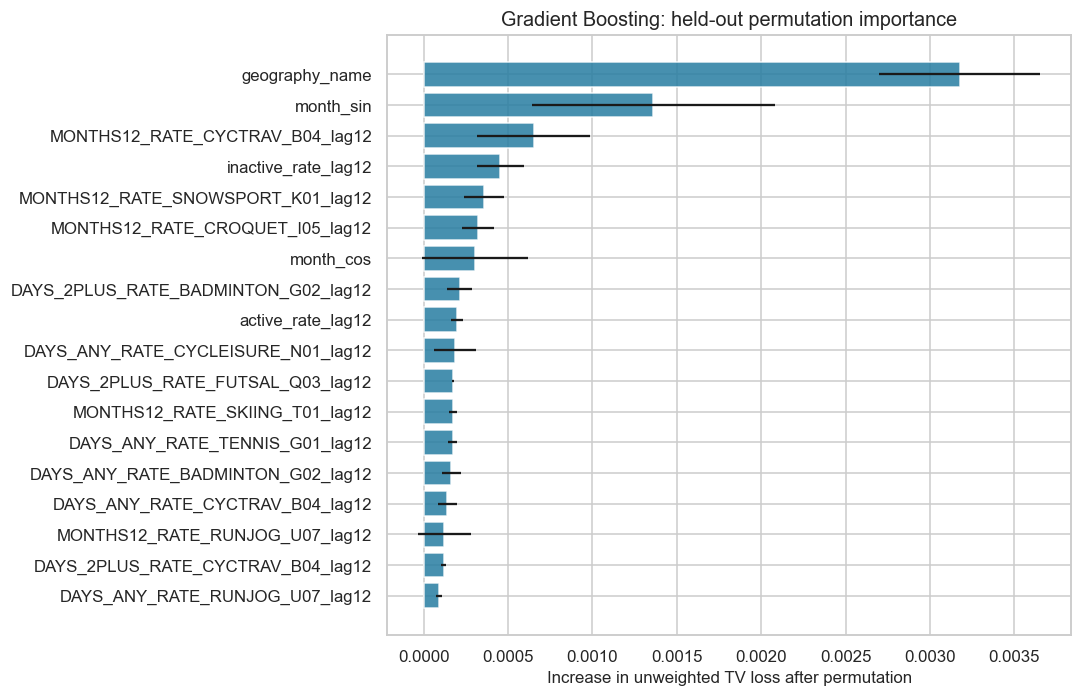

,feature,importance_mean,importance_sd
383,geography_name,0.003175,0.000478
1,month_sin,0.001361,0.000721
12,MONTHS12_RATE_CYCTRAV_B04_lag12,0.000651,0.000333
5,inactive_rate_lag12,0.000453,0.000139
59,MONTHS12_RATE_SNOWSPORT_K01_lag12,0.000359,0.000118
48,MONTHS12_RATE_CROQUET_I05_lag12,0.000324,0.000095
2,month_cos,0.000304,0.000315
283,DAYS_2PLUS_RATE_BADMINTON_G02_lag12,0.000213,0.000075
7,active_rate_lag12,0.000196,0.000036
202,DAYS_ANY_RATE_CYCLEISURE_N01_lag12,0.000184,0.000124


In [14]:
ridge = fitted_models['Ridge']
ridge_feature_names = ridge.named_steps['preprocessor'].get_feature_names_out()
ridge_coefficients = ridge.named_steps['model'].coef_
ridge_importance = pd.DataFrame({
    'feature': ridge_feature_names,
    'inactive_vs_active': ridge_coefficients[0],
    'fairly_vs_active': ridge_coefficients[1],
})
ridge_importance['mean_abs_coefficient'] = ridge_importance[
    ['inactive_vs_active', 'fairly_vs_active']
].abs().mean(axis=1)
ridge_top = ridge_importance.nlargest(18, 'mean_abs_coefficient').sort_values('mean_abs_coefficient')

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(ridge_top['feature'], ridge_top['mean_abs_coefficient'], color='#577590')
ax.set(title='Ridge transparency: largest standardised coefficients',
       xlabel='Mean absolute coefficient across two log-ratio targets', ylabel='')
plt.tight_layout()
plt.show()
display(ridge_top.sort_values('mean_abs_coefficient', ascending=False).head(18))
display(ridge_importance.loc[
    ridge_importance['feature'].str.contains(r'covid_.*flag', regex=True)
].rename(columns={'feature': 'explicit COVID calendar feature'}))


def alr_total_variation_loss(actual_coordinates, predicted_coordinates):
    actual = alr_to_shares(actual_coordinates)
    predicted = alr_to_shares(predicted_coordinates)
    return float(np.mean(.5 * np.abs(actual - predicted).sum(axis=1)))


if SELECTED_MODEL != 'Seasonal naive':
    sample = holdout.sample(n=min(256, len(holdout)), random_state=RANDOM_STATE)
    scorer = make_scorer(alr_total_variation_loss, greater_is_better=False)
    permutation = permutation_importance(
        fitted_models[SELECTED_MODEL], sample[model_features], shares_to_alr(sample[TARGETS]),
        scoring=scorer, n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1,
    )
    permutation_table = pd.DataFrame({
        'feature': model_features,
        'importance_mean': permutation.importances_mean,
        'importance_sd': permutation.importances_std,
    }).sort_values('importance_mean', ascending=False)
    permutation_top = permutation_table.head(18).sort_values('importance_mean')
    fig, ax = plt.subplots(figsize=(10, 6.5))
    ax.barh(permutation_top['feature'], permutation_top['importance_mean'],
            xerr=permutation_top['importance_sd'], color='#277da1', alpha=.85)
    ax.set(title=f'{SELECTED_MODEL}: held-out permutation importance',
           xlabel='Increase in unweighted TV loss after permutation', ylabel='')
    plt.tight_layout()
    plt.show()
    display(permutation_table.head(20))
else:
    permutation_table = pd.DataFrame()
    print('Seasonal naive was selected; model-based permutation importance is not applicable.')

## 11. Reproducible conclusion

The printed conclusion is generated from the cross-validation choice and untouched final-year metrics. A lower total-variation error is better. Positive skill means improvement over the seasonal-naive benchmark.

This is an evaluation notebook, not a guarantee of future performance. Before a real deployment, repeat the rolling monitoring each month, inspect drift in activity-variable coverage, and retrain only after the outcome for the new month becomes available.

In [15]:
selected_test = test_metrics.loc[test_metrics['model'].eq(SELECTED_MODEL)].iloc[0]
selected_cv = cv_comparison.loc[cv_comparison['model'].eq(SELECTED_MODEL)].iloc[0]
conclusion = {
    'forecast_definition': 'Fixed-origin 12-month forecast using lag-12 survey features',
    'development_months': '2016-11 to 2022-10 after 12-month lag warm-up',
    'independent_test_months': '2022-11 to 2023-10',
    'selected_model': SELECTED_MODEL,
    'mean_cv_weighted_tv': selected_cv['mean_weighted_tv'],
    'test_weighted_tv': selected_test['weighted_tv'],
    'test_skill_vs_seasonal': selected_test['skill_vs_seasonal'],
    'activity_inputs': '372 activity rates, all lagged 12 months',
    'covid_handling': 'Current-month and lag-12-source calendar flags; exact periods shaded; split CV errors reported',
    'test_period_covid_status': 'No test outcome month is inside a defined restriction period; 3 months use Omicron-era lag-12 inputs',
    'survey_weighting': 'Annual wt_final; monthly wt_time (already applied upstream)',
    'fit_and_metric_weight': 'effective_n only',
}
display(pd.DataFrame([conclusion]).T.rename(columns={0: 'result'}))
print('\nSaved outputs:')
for path in sorted(OUTPUT_DIR.glob('monthly_forecast_*.csv')):
    print(' -', path.relative_to(PROJECT_ROOT))

assert SELECTED_MODEL in {'Seasonal naive', 'Ridge', 'Random Forest', 'Gradient Boosting'}
assert test_metrics['weighted_tv'].notna().all()
assert prediction_output.filter(like='_rate').notna().all().all()
print('\nForecast notebook completed without failed checks.')

,result
forecast_definition,Fixed-origin 12-month forecast using lag-12 su...
development_months,2016-11 to 2022-10 after 12-month lag warm-up
independent_test_months,2022-11 to 2023-10
selected_model,Gradient Boosting
mean_cv_weighted_tv,0.104092
test_weighted_tv,0.1023
test_skill_vs_seasonal,0.266256
activity_inputs,"372 activity rates, all lagged 12 months"
covid_handling,Current-month and lag-12-source calendar flags...
test_period_covid_status,No test outcome month is inside a defined rest...



Saved outputs:
 - physical_activity_analysis\prediction_outputs\monthly_forecast_alr_sensitivity.csv
 - physical_activity_analysis\prediction_outputs\monthly_forecast_covid_sensitivity.csv
 - physical_activity_analysis\prediction_outputs\monthly_forecast_cv_fold_metrics.csv
 - physical_activity_analysis\prediction_outputs\monthly_forecast_cv_metrics.csv
 - physical_activity_analysis\prediction_outputs\monthly_forecast_effective_n_sensitivity.csv
 - physical_activity_analysis\prediction_outputs\monthly_forecast_holdout_predictions.csv
 - physical_activity_analysis\prediction_outputs\monthly_forecast_interval_coverage.csv
 - physical_activity_analysis\prediction_outputs\monthly_forecast_test_metrics.csv
 - physical_activity_analysis\prediction_outputs\monthly_forecast_test_target_metrics.csv

Forecast notebook completed without failed checks.
